# Acesso a LLMs via API - Múltiplos Providers
**Providers cobertos:** OpenAI · Groq · Google


Para este código não é necessário que a execução seja feita em GPU, apenas em CPU.

## 1. Instalação de dependências

In [ ]:
# Instala os SDKs de cada provider
!pip install -q openai groq google-genai --quiet


## 2. Configuração das chaves de API

**Como adicionar suas chaves no Google Colab:**
1. No menu lateral esquerdo, clique no ícone de **🔑 chave** (Secrets)
2. Clique em **+ Adicionar novo secret**
3. Adicione cada chave com os nomes exatos abaixo:
   - `OPENAI_API_KEY` *(opcional veja nota abaixo)*
   - `GROQ_API_KEY`
   - `GOOGLE_API_KEY`
4. Ative o toggle **"Acesso ao notebook"** para cada uma

> ⚠️ **A OpenAI exige uma conta paga:** Diferente de outros provedores, a API da OpenAI não oferece um plano gratuito com limites de uso generosos. Para utilizá-la, é necessário ter uma conta com créditos adicionados em [platform.openai.com](https://platform.openai.com/account/billing). Esta seção é **opcional** — os demais provedores (Groq e Google) disponibilizam planos gratuitos suficientes para realizar os exercícios do notebook.

**Onde obter cada chave de API:**
- `OPENAI_API_KEY`: https://platform.openai.com/api-keys
- `GROQ_API_KEY`: https://console.groq.com/keys
- `GOOGLE_API_KEY`: https://aistudio.google.com/app/api-keys


### MILESTONE 1

Carregue pelo menos uma das chaves de algum dos provedores de serviços de API. Ao carregar as chaves, deve aparecer a mensagem: Nome do provedor : ok

In [ ]:
from google.colab import userdata

# Lê as chaves de API do Secrets do Colab
# Se a chave não existir, retorna None e o provider correspondente ficará indisponível
def get_secret(key_name):
    try:
        return userdata.get(key_name)
    except Exception:
        print(f"[AVISO] Secret '{key_name}' não encontrado. Configure no painel de Secrets.")
        return None

OPENAI_API_KEY  = get_secret("OPENAI_API_KEY")
GROQ_API_KEY    = get_secret("GROQ_API_KEY")
GOOGLE_API_KEY  = get_secret("GOOGLE_API_KEY")

print("Chaves carregadas:")
print(f"  OpenAI : {'ok' if OPENAI_API_KEY  else 'não configurada (opcional)'}")
print(f"  Groq   : {'ok' if GROQ_API_KEY    else 'não configurada'}")
print(f"  Google : {'ok' if GOOGLE_API_KEY  else 'não configurada'}")

Chaves carregadas:
  OpenAI : ok
  Groq   : ok
  Google : ok


## 3. Inicialização dos clientes

In [ ]:
import openai
import groq
from google import genai as google_genai

# ── OpenAI ──────────────────────────────────────────────────────────────────
openai_client = openai.OpenAI(api_key=OPENAI_API_KEY) if OPENAI_API_KEY else None

# ── Groq ────────────────────────────────────────────────────────────────────
# Groq usa hardware LPU próprio → velocidade de inferência muito alta
groq_client = groq.Groq(api_key=GROQ_API_KEY) if GROQ_API_KEY else None

# ── Google Gemini ────────────────────────────────────────────────────────────
google_client = google_genai.Client(api_key=GOOGLE_API_KEY) if GOOGLE_API_KEY else None

print("Clientes inicializados com sucesso.")


Clientes inicializados com sucesso.


## 4. OpenAI - GPT-4o e GPT-4o mini

In [ ]:
def chamar_openai(prompt, modelo="gpt-4o-mini", system="Você é um assistente útil.",
                  temperature=0.7, max_tokens=512):
    """
    Chama um modelo da OpenAI via chat completions.

    Args:
        prompt       : mensagem do usuário
        modelo       : ID do modelo (ex: 'gpt-4o', 'gpt-4o-mini')
        system       : conteúdo do system prompt
        temperature  : criatividade da resposta (0 = determinístico, 1 = criativo)
        max_tokens   : limite de tokens na resposta

    Returns:
        str: texto da resposta gerada
    """
    if not openai_client:
        return "[ERRO] Cliente OpenAI não inicializado. Verifique a API key."

    resposta = openai_client.chat.completions.create(
        model=modelo,
        temperature=temperature,
        max_tokens=max_tokens,
        messages=[
            {"role": "system", "content": system},
            {"role": "user",   "content": prompt}
        ]
    )
    return resposta.choices[0].message.content

In [ ]:
# ── Testando GPT-4o-mini (modelo econômico, rápido) ─────────────────────────
pergunta = "O que é um transformer em 3 frases?"

print("=" * 60)
print("Modelo: gpt-4o-mini")
print("=" * 60)
resposta_mini = chamar_openai(pergunta, modelo="gpt-4o-mini")
print(resposta_mini)

Modelo: gpt-4o-mini
Um transformer é um modelo de aprendizado de máquina desenvolvido para processamento de linguagem natural, introduzido no artigo "Attention is All You Need" em 2017. Ele utiliza um mecanismo de atenção para ponderar a relevância de diferentes palavras em uma sequência, permitindo que o modelo capture dependências de longo alcance. Os transformers são a base de muitos modelos avançados, como o BERT e o GPT, sendo amplamente usados em tarefas de tradução, resumo e geração de texto.


In [ ]:
# ── Testando GPT-4o (modelo um pouco melhor) ───────────────────────────
print("=" * 60)
print("Modelo: gpt-4o")
print("=" * 60)
resposta_4o = chamar_openai(pergunta, modelo="gpt-4o")
print(resposta_4o)

Modelo: gpt-4o
Um transformer é um modelo de aprendizado de máquina projetado para lidar com dados sequenciais, como texto, utilizando uma arquitetura baseada em mecanismos de atenção. Ele permite que o modelo atribua diferentes pesos a diferentes palavras em uma sequência, melhorando a capacidade de capturar dependências contextuais de longo alcance. Essa arquitetura tem sido fundamental no avanço de modelos de linguagem natural, como o GPT e o BERT.


In [ ]:
# ── Testando com system prompt customizado ────────────────────────────────────
system_tecnico = """
Você é um professor de deep learning do MIT.
Responda de forma técnica, citando arquitetura e matemática quando relevante.
Use no máximo 5 frases.
"""

print("=" * 60)
print("Modelo: gpt-4o | System: professor MIT")
print("=" * 60)
resposta_tecnica = chamar_openai(pergunta, modelo="gpt-4o", system=system_tecnico)
print(resposta_tecnica)

Modelo: gpt-4o | System: professor MIT
Um transformer é uma arquitetura de rede neural introduzida pelo paper "Attention is All You Need" de Vaswani et al. em 2017, que utiliza mecanismos de atenção para processar sequências de dados, como texto, de forma mais eficaz do que RNNs ou LSTMs. A atenção no transformer é implementada através de múltiplas cabeças de self-attention, permitindo que o modelo aprenda a dar pesos diferentes a partes distintas da entrada. A arquitetura é composta por blocos de codificador e decodificador, onde cada bloco contém camadas de atenção e feed-forward totalmente conectadas, com camadas de normalização e dropout para estabilidade e regularização.


## 5. Groq - Llama 3.3 70B e Llama 3.1 8B

In [ ]:
def chamar_groq(prompt, modelo="llama-3.3-70b-versatile", system="Você é um assistente.",
                temperature=0.7, max_tokens=512):
    """
    Chama um modelo hospedado no Groq.
    O SDK do Groq usa a mesma interface do OpenAI (chat.completions.create).

    Modelos disponíveis no Groq:
      - llama-3.3-70b-versatile  → melhor qualidade, mais lento
      - llama-3.1-8b-instant     → mais rápido, menor qualidade
      - gpt-oss-120b             → modelo GPT open source
      - mixtral-8x7b-32768       → Mixtral MoE da Mistral AI

    Returns:
        str: texto da resposta gerada
    """
    if not groq_client:
        return "[ERRO] Cliente Groq não inicializado. Verifique a API key."

    resposta = groq_client.chat.completions.create(
        model=modelo,
        temperature=temperature,
        max_tokens=max_tokens,
        messages=[
            {"role": "system", "content": system},
            {"role": "user",   "content": prompt}
        ]
    )
    return resposta.choices[0].message.content

In [ ]:
# ── Testando Llama 3.3 70B no Groq ───────────────────────────────────────────
# Groq é conhecido pela velocidade: ~500-800 tokens/segundo
import time

print("=" * 60)
print("Modelo: llama-3.3-70b-versatile (Groq)")
print("=" * 60)

inicio = time.time()
resposta_llama70b = chamar_groq(pergunta, modelo="llama-3.3-70b-versatile")
tempo = time.time() - inicio

print(resposta_llama70b)
print(f"\n⏱ Tempo de resposta: {tempo:.2f}s")

Modelo: llama-3.3-70b-versatile (Groq)
Um transformer é um tipo de modelo de aprendizado de máquina projetado para processar sequências de dados, como texto ou áudio, e realizar tarefas como tradução, resumo e geração de texto. O transformer foi introduzido em 2017 por Vaswani et al. e desde então se tornou um modelo fundamental em muitas aplicações de processamento de linguagem natural. O transformer é baseado em uma arquitetura de self-atenção, que permite que o modelo se concentre em diferentes partes da sequência de entrada e capture relações complexas entre as palavras ou tokens.

⏱ Tempo de resposta: 0.86s


In [ ]:
# ── Testando Llama 3.1 8B no Groq (modelo ultra-rápido e leve) ───────────────
print("=" * 60)
print("Modelo: llama-3.1-8b-instant (Groq)")
print("=" * 60)

inicio = time.time()
resposta_llama8b = chamar_groq(pergunta, modelo="llama-3.1-8b-instant")
tempo = time.time() - inicio

print(resposta_llama8b)
print(f"\n⏱ Tempo de resposta: {tempo:.2f}s")

Modelo: llama-3.1-8b-instant (Groq)
Um Transformer é um modelo de linguagem artificial desenvolvido por Google em 2017 que pode entender e gerar texto como um humano. Ele é baseado em uma rede neural profunda que pode aprender padrões e relações entre as palavras em um texto. Com isso, os Transformers podem realizar tarefas como resumo de texto, tradução de idiomas e geração de texto.

⏱ Tempo de resposta: 0.39s


In [ ]:
# ── Testando GPT OSS 120b no Groq (modelo open-source da OpenAI) ───────────────
print("=" * 60)
print("Modelo: openai/gpt-oss-120b (Groq)")
print("=" * 60)

inicio = time.time()
resposta_gpt = chamar_groq(pergunta, modelo="openai/gpt-oss-120b")
tempo = time.time() - inicio

print(resposta_gpt)
print(f"\n⏱ Tempo de resposta: {tempo:.2f}s")

Modelo: openai/gpt-oss-120b (Groq)
Um Transformer é uma arquitetura de rede neural baseada em mecanismos de atenção que permite que o modelo pese a importância de diferentes partes de uma sequência de entrada simultaneamente. Essa abordagem substitui o uso de recorrências ou convoluções, facilitando o processamento paralelo e escalável de textos longos. Ela se tornou a base de modelos avançados de linguagem, como BERT e GPT, alcançando desempenho de ponta em diversas tarefas de NLP.

⏱ Tempo de resposta: 0.45s


## 6. Google - Gemini 2.5 Flash e Gemini 2.0 Flash


In [ ]:
from google.genai import types as genai_types

def chamar_google(prompt, modelo="gemini-2.5-flash", system=None,
                  temperature=0.7, max_tokens=512):
    """
    Modelos disponíveis:
      - gemini-2.5-flash    → mais recente, pensamento adaptativo, contexto 1M
      - gemini-2.0-flash    → rápido, multimodal nativo, contexto 1M
      - gemini-2.5-pro      → mais capaz, raciocínio avançado

    Nota: o novo SDK usa client.models.generate_content() em vez de
    GenerativeModel.generate_content(). A interface muda para padrão cliente explícito.

    Returns:
        str: texto da resposta gerada
    """
    if not google_client:
        return "[ERRO] Google API key não configurada."

    config = genai_types.GenerateContentConfig(
        temperature=temperature,
        max_output_tokens=max_tokens,
        system_instruction=system  # None = sem system prompt
    )

    resposta = google_client.models.generate_content(
        model=modelo,
        contents=prompt,
        config=config
    )
    return resposta.text


In [ ]:
# ── Testando Gemini 2.5 Flash ─────────────────────────────────────────────────
print("=" * 60)
print("Modelo: gemini-2.5-flash (Google)")
print("=" * 60)
resposta_flash = chamar_google(pergunta, modelo="gemini-2.5-flash")
print(resposta_flash)

Modelo: gemini-2.5-flash (Google)
Um Transformer é uma arquitetura de rede neural que revolucionou o processamento de linguagem natural


In [ ]:
# ── Testando Gemini 2.0 Flash ───────────────────────────────────────────────
print("=" * 60)
print("Modelo: gemini-2.0-flash (Google)")
print("=" * 60)
resposta_pro = chamar_google(pergunta, modelo="gemini-2.0-flash")
print(resposta_pro)

Modelo: gemini-2.0-flash (Google)
Um Transformer é um modelo de rede neural que revolucionou o processamento de linguagem natural. Ele se baseia em um mecanismo de autoatenção que permite ao modelo ponderar a importância de diferentes partes da entrada ao processá-la. Essa arquitetura permite que o modelo capture dependências complexas e relacionamentos de longo alcance nos dados, tornando-o altamente eficaz para tarefas como tradução, resumo e geração de texto.



In [ ]:
# ── Testando Gemini com system prompt ─────────────────────────────────────────
system_simples = "Você é um professor do ensino médio. Explique de forma simples, sem jargão técnico."

print("=" * 60)
print("Modelo: gemini-2.5-flash | System: professor ensino médio")
print("=" * 60)
resposta_simples = chamar_google(pergunta, modelo="gemini-2.5-flash", system=system_simples)
print(resposta_simples)


Modelo: gemini-2.5-flash | System: professor ensino médio
Olá, pessoal! Pensem assim:

1.  Um Transformer é como um "cérebro


## 7. Wrapper unificado - chamando qualquer provider com a mesma interface

In [ ]:
# Mapa de modelos disponíveis por provider
# Formato: "provider/modelo" → função correspondente
MODELOS_DISPONIVEIS = {
    # OpenAI
    "openai/gpt-4o":           lambda p, s, t, m: chamar_openai(p, "gpt-4o", s, t, m),
    "openai/gpt-4o-mini":      lambda p, s, t, m: chamar_openai(p, "gpt-4o-mini", s, t, m),

    # Groq
    "groq/llama-3.3-70b":      lambda p, s, t, m: chamar_groq(p, "llama-3.3-70b-versatile", s, t, m),
    "groq/llama-3.1-8b":       lambda p, s, t, m: chamar_groq(p, "llama-3.1-8b-instant", s, t, m),
    "groq/gpt-oss-120b":       lambda p, s, t, m: chamar_groq(p, "openai/gpt-oss-120b", s, t, m),

    # Google
    "google/gemini-2.5-flash": lambda p, s, t, m: chamar_google(p, "gemini-2.5-flash", s, t, m),
    "google/gemini-2.0-flash": lambda p, s, t, m: chamar_google(p, "gemini-2.0-flash", s, t, m),
}


def chamar_modelo(modelo_id, prompt, system="Você é um assistente útil.",
                  temperature=0.7, max_tokens=512):
    """
    Interface unificada para chamar qualquer provider com a mesma assinatura.

    Args:
        modelo_id   : chave no formato 'provider/modelo' (ver MODELOS_DISPONIVEIS)
        prompt      : mensagem do usuário
        system      : system prompt
        temperature : criatividade (0 a 1)
        max_tokens  : limite de tokens na resposta

    Returns:
        str: resposta do modelo, ou mensagem de erro
    """
    if modelo_id not in MODELOS_DISPONIVEIS:
        disponiveis = "\n".join(f"  - {k}" for k in MODELOS_DISPONIVEIS)
        return f"[ERRO] Modelo '{modelo_id}' não encontrado. Disponíveis:\n{disponiveis}"

    try:
        fn = MODELOS_DISPONIVEIS[modelo_id]
        return fn(prompt, system, temperature, max_tokens)
    except Exception as e:
        return f"[ERRO] Falha ao chamar '{modelo_id}': {str(e)}"


print("Modelos disponíveis no wrapper:")
for modelo_id in MODELOS_DISPONIVEIS:
    print(f"  - {modelo_id}")


Modelos disponíveis no wrapper:
  - openai/gpt-4o
  - openai/gpt-4o-mini
  - groq/llama-3.3-70b
  - groq/llama-3.1-8b
  - groq/gpt-oss-120b
  - google/gemini-2.5-flash
  - google/gemini-2.0-flash


In [ ]:
# ── Usando o wrapper unificado ────────────────────────────────────────────────
# A mesma chamada funciona para qualquer provider

pergunta_teste = "Explique o conceito de atenção (attention) em redes neurais em 2 frases."

for modelo_id in ["openai/gpt-4o-mini", "groq/llama-3.3-70b", "google/gemini-2.5-flash"]:
    print(f"\n{'=' * 60}")
    print(f"Modelo: {modelo_id}")
    print("=" * 60)
    resposta = chamar_modelo(modelo_id, pergunta_teste)
    print(resposta)


Modelo: openai/gpt-4o-mini
O conceito de atenção em redes neurais refere-se a um mecanismo que permite ao modelo focar em partes específicas de uma entrada ao fazer previsões, em vez de processar toda a informação de forma uniforme. Isso é especialmente útil em tarefas como tradução de idiomas e processamento de linguagem natural, onde diferentes palavras ou partes de uma sequência podem ter diferentes níveis de importância contextual.

Modelo: groq/llama-3.3-70b
O conceito de atenção (attention) em redes neurais refere-se a uma técnica que permite que o modelo se concentre em partes específicas dos dados de entrada que são mais relevantes para a tarefa em questão, ao invés de processar todos os dados igualmente. Isso é alcançado por meio de mecanismos de atenção que calculam pesos de importância para diferentes partes dos dados e os utilizam para ponderar as contribuições de cada parte no cálculo da saída final.

Modelo: google/gemini-2.5-flash
A atenção em redes neurais permite que 

## 8. Comparação de velocidade entre providers

In [ ]:
import time

def medir_latencia(modelo_id, prompt, n_execucoes=3, **kwargs):
    """
    Mede a latência média de um modelo em N execuções.

    Args:
        modelo_id    : chave no formato 'provider/modelo'
        prompt       : pergunta a ser enviada
        n_execucoes  : número de chamadas para calcular a média

    Returns:
        dict: {'modelo': str, 'latencia_media_s': float, 'tokens_resposta': int}
    """
    tempos = []
    ultima_resposta = ""

    for i in range(n_execucoes):
        inicio = time.time()
        ultima_resposta = chamar_modelo(modelo_id, prompt, **kwargs)
        tempos.append(time.time() - inicio)

    return {
        "modelo": modelo_id,
        "latencia_media_s": round(sum(tempos) / len(tempos), 2),
        "latencia_min_s":   round(min(tempos), 2),
        "latencia_max_s":   round(max(tempos), 2),
        "tokens_aprox":     len(ultima_resposta.split())
    }

### 🚀 MILESTONE 2

Da lista `modelos_benchmark`, selecione pelo menos dois modelos para fazer a comparação. Se você configurou apenas um provedor, selecione os dois modelos do mesmo provedor. Se configurou provedores diferentes, selecione pelo menos um modelo de cada, descomentando a linha abaixo. Como exemplo estão os modelos `groq/llama-3.1-8b` e `google/gemini-2.0-flash`.

In [ ]:
# ── Benchmark de latência entre providers ─────────────────────────────────────
# Usa max_tokens=100 para manter as respostas curtas e a comparação justa

modelos_benchmark = [
    # "openai/gpt-4o",
    # "openai/gpt-4o-mini",
    # "groq/llama-3.3-70b",
    "groq/llama-3.1-8b",
    # "groq/gpt-oss-120b",
    # "google/gemini-2.5-flash",
    "google/gemini-2.0-flash",
]

prompt_bench = "O que é backpropagation?"
resultados = []

for modelo_id in modelos_benchmark:
    print(f"Medindo: {modelo_id}...")
    resultado = medir_latencia(modelo_id, prompt_bench, n_execucoes=2, max_tokens=100)
    resultados.append(resultado)
    print(f"  → média: {resultado['latencia_media_s']}s")

print("\n Benchmark concluído.")

Medindo: groq/llama-3.1-8b...
  → média: 0.41s
Medindo: google/gemini-2.0-flash...
  → média: 1.58s

 Benchmark concluído.


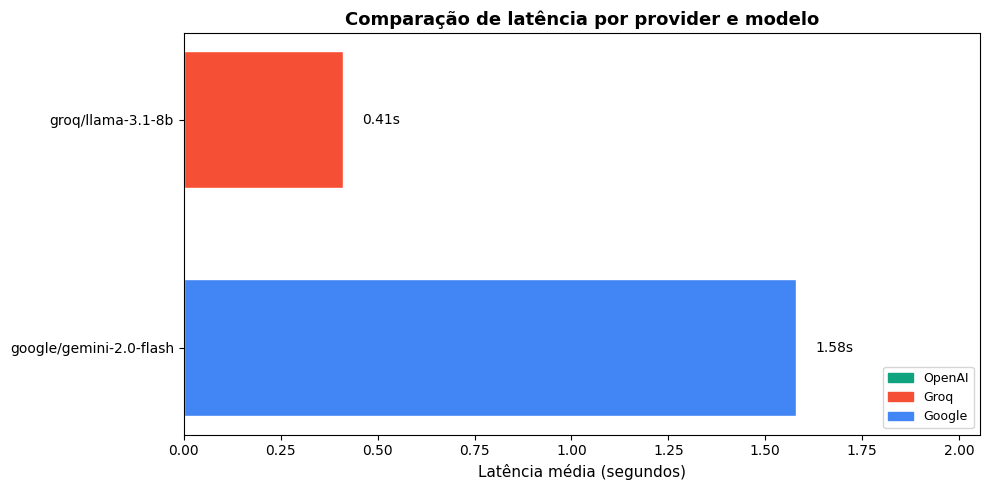

In [ ]:
import matplotlib.pyplot as plt

def plotar_benchmark(resultados):
    """
    Gera um gráfico de barras com a latência média por modelo.

    Args:
        resultados: lista de dicts retornados por medir_latencia()
    """
    # Ordena do mais rápido ao mais lento
    resultados_ord = sorted(resultados, key=lambda x: x["latencia_media_s"])

    modelos  = [r["modelo"] for r in resultados_ord]
    latencias = [r["latencia_media_s"] for r in resultados_ord]

    # Colore as barras por provider
    cores = []
    for m in modelos:
        if m.startswith("openai"):   cores.append("#10a37f")  # verde OpenAI
        elif m.startswith("groq"):   cores.append("#f55036")  # laranja Groq
        elif m.startswith("google"): cores.append("#4285f4")  # azul Google
        else:                         cores.append("#9747ff")  # roxo Together

    fig, ax = plt.subplots(figsize=(10, 5))
    barras = ax.barh(modelos, latencias, color=cores, edgecolor="white", height=0.6)

    # Adiciona o valor dentro de cada barra
    for barra, val in zip(barras, latencias):
        ax.text(barra.get_width() + 0.05, barra.get_y() + barra.get_height() / 2,
                f"{val}s", va="center", fontsize=10)

    ax.set_xlabel("Latência média (segundos)", fontsize=11)
    ax.set_title("Comparação de latência por provider e modelo", fontsize=13, fontweight="bold")
    ax.set_xlim(0, max(latencias) * 1.3)
    ax.invert_yaxis()  # mais rápido no topo

    # Legenda manual por provider
    from matplotlib.patches import Patch
    legenda = [
        Patch(color="#10a37f", label="OpenAI"),
        Patch(color="#f55036", label="Groq"),
        Patch(color="#4285f4", label="Google"),
    ]
    ax.legend(handles=legenda, loc="lower right", fontsize=9)

    plt.tight_layout()
    plt.show()


plotar_benchmark(resultados)

Na comparação realizada, qual modelo foi mais rápido? Por que esse resultado pode ter ocorrido?

## 9. Comparando respostas de múltiplos modelos em paralelo


In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def comparar_modelos(prompt, modelos, system="Você é um assistente útil.",
                     max_tokens=300, temperature=0.7):
    """
    Chama múltiplos modelos em paralelo e retorna as respostas de cada um.
    Usa ThreadPoolExecutor para enviar as chamadas simultaneamente,
    reduzindo o tempo total de espera.

    Args:
        prompt      : pergunta enviada a todos os modelos
        modelos     : lista de modelo_ids (chaves de MODELOS_DISPONIVEIS)
        system      : system prompt comum a todos
        max_tokens  : limite de tokens por resposta
        temperature : criatividade

    Returns:
        dict: {modelo_id: resposta_str}
    """
    def chamar(modelo_id):
        inicio = time.time()
        resposta = chamar_modelo(modelo_id, prompt, system, temperature, max_tokens)
        duracao = round(time.time() - inicio, 2)
        return modelo_id, resposta, duracao

    resultados = {}

    # Chamadas paralelas — todas são enviadas ao mesmo tempo
    with ThreadPoolExecutor(max_workers=len(modelos)) as executor:
        futures = {executor.submit(chamar, m): m for m in modelos}
        for future in as_completed(futures):
            modelo_id, resposta, duracao = future.result()
            resultados[modelo_id] = {"resposta": resposta, "tempo_s": duracao}

    return resultados

### MILESTONE 3
Selecione novamente dois modelos como no MILESTONE 2 e compare as respostas de ambos. Qual você escolheria em caso de uma implementação? Com base na qualidade da resposta e no tempo de inferência.

In [ ]:
# ── Comparando respostas de modelos para a mesma pergunta ───────────────────
pergunta_comparacao = """
Você é um assistente técnico de uma empresa de software.
Um desenvolvedor júnior pergunta: "Quando devo usar um banco de dados relacional
vs. um banco NoSQL?"
Responda de forma direta, com exemplos práticos. Máximo 4 parágrafos.
"""

modelos_comparar = [
    # "openai/gpt-4o",
    # "openai/gpt-4o-mini",
    # "groq/llama-3.3-70b",
    "groq/llama-3.1-8b",
    # "groq/gpt-oss-120b",
    # "google/gemini-2.5-flash",
    "google/gemini-2.0-flash",
]

print("Enviando chamadas em paralelo...")
comparacao = comparar_modelos(pergunta_comparacao, modelos_comparar, max_tokens=400)

# Exibe os resultados organizados
for modelo_id, dados in comparacao.items():
    print(f"\n{'=' * 60}")
    print(f"{modelo_id}  |  ⏱ {dados['tempo_s']}s")
    print("=" * 60)
    print(dados["resposta"])

Enviando chamadas em paralelo...

groq/llama-3.1-8b  |  ⏱ 0.82s
Excelente pergunta!

Em geral, você deve usar um banco de dados relacional (RDBMS) quando:

* Você precisa de uma modelagem de dados estruturada e flexível, com relacionamentos complexos entre as tabelas. Exemplo: uma plataforma de e-commerce que requer uma hierarquia de categorias e subcategorias.
* Você precisa de uma alta consistência e isolamento de transação, ou seja, quando a integridade dos dados é fundamental. Exemplo: um sistema de gestão de contas bancárias que requer que as transações sejam processadas de forma segura e imutável.

Por outro lado, é recomendável usar um banco NoSQL quando:

* Você precisa de uma modelagem de dados flexível e escalável, que possa se adaptar a um grande volume de dados não estruturados. Exemplo: um sistema de gerenciamento de imagens em tempo real que recebe milhões de imagens por dia.
* Você precisa de uma alta velocidade de processamento e escalabilidade horizontal, sem a necessi

## 10. Tabela de referência - modelos e providers

Esta é uma tabela de alguns modelos de diferentes provedores de inteligência artificial. Devido às constantes mudanças, recomenda-se verificar os limites e atualizações de cada modelo diretamente na página de cada provedor.

In [ ]:
import pandas as pd

# Tabela de referência dos modelos usados neste notebook
# Preços aproximados referentes a maio/2025 — consulte sempre a documentação oficial
tabela_modelos = [
    {"Provider": "OpenAI",  "Modelo ID (wrapper)": "openai/gpt-4o",          "Modelo real": "gpt-4o",                  "Tipo": "Proprietário", "Input $/1M tok": "$2.50",  "Output $/1M tok": "$10.00", "Contexto": "128k"},
    {"Provider": "OpenAI",  "Modelo ID (wrapper)": "openai/gpt-4o-mini",      "Modelo real": "gpt-4o-mini",            "Tipo": "Proprietário", "Input $/1M tok": "$0.15",  "Output $/1M tok": "$0.60",  "Contexto": "128k"},
    {"Provider": "Groq",    "Modelo ID (wrapper)": "groq/llama-3.3-70b",      "Modelo real": "llama-3.3-70b-versatile", "Tipo": "Open-source",  "Input $/1M tok": "$0.59",  "Output $/1M tok": "$0.79",  "Contexto": "128k"},
    {"Provider": "Groq",    "Modelo ID (wrapper)": "groq/llama-3.1-8b",       "Modelo real": "llama-3.1-8b-instant",   "Tipo": "Open-source",  "Input $/1M tok": "$0.05",  "Output $/1M tok": "$0.08",  "Contexto": "128k"},
    {"Provider": "Groq",    "Modelo ID (wrapper)": "groq/gpt-oss-120b",       "Modelo real": "gpt-oss-120b",           "Tipo": "Open-source",  "Input $/1M tok": "$0.20",  "Output $/1M tok": "$0.20",  "Contexto": "8k"},
    {"Provider": "Google",  "Modelo ID (wrapper)": "google/gemini-2.5-flash", "Modelo real": "gemini-2.5-flash",       "Tipo": "Proprietário", "Input $/1M tok": "$0.15",  "Output $/1M tok": "$0.60",  "Contexto": "1M"},
    {"Provider": "Google",  "Modelo ID (wrapper)": "google/gemini-2.0-flash", "Modelo real": "gemini-2.0-flash",       "Tipo": "Proprietário", "Input $/1M tok": "$0.10",  "Output $/1M tok": "$0.40",  "Contexto": "1M"},
]

df = pd.DataFrame(tabela_modelos)
df.set_index("Modelo ID (wrapper)", inplace=True)

pd.set_option("display.max_colwidth", 50)
pd.set_option("display.width", 120)
display(df)


,Provider,Modelo real,Tipo,Input $/1M tok,Output $/1M tok,Contexto
Modelo ID (wrapper),,,,,,
openai/gpt-4o,OpenAI,gpt-4o,Proprietário,$2.50,$10.00,128k
openai/gpt-4o-mini,OpenAI,gpt-4o-mini,Proprietário,$0.15,$0.60,128k
groq/llama-3.3-70b,Groq,llama-3.3-70b-versatile,Open-source,$0.59,$0.79,128k
groq/llama-3.1-8b,Groq,llama-3.1-8b-instant,Open-source,$0.05,$0.08,128k
groq/gpt-oss-120b,Groq,gpt-oss-120b,Open-source,$0.20,$0.20,8k
google/gemini-2.5-flash,Google,gemini-2.5-flash,Proprietário,$0.15,$0.60,1M
google/gemini-2.0-flash,Google,gemini-2.0-flash,Proprietário,$0.10,$0.40,1M
